# Cancer Detection: Feature Selection & Correlation Analysis

This notebook identifies the most important features for cancer detection using Pearson correlation.

**Process:**
1. Drop highly correlated features (redundant information)
2. Rank remaining features by their correlation with the diagnosis label
3. Visualize why features matter

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("metadata_(for_scores).csv")

# --- label and features ---
label_col = "skin_cancer_diagnosis"
features = [
 'melanoma_color_count','melanoma_colors','hue_variance',
 'saturation_variance','value_variance','mabrouk_asymmetry_score',
 'avg_asymmetry_score','worst_score','Polsby-Popper','convexity_score',
 'lesion_red_share','lesion_green_share','lesion_blue_share',
 'lesion_skin_red_diff','lesion_skin_green_diff','lesion_skin_blue_diff',
 'lesion_skin_rgb_distance'
]

# --- checks ---
missing = [c for c in features + [label_col] if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in df: {missing}")

X = df[features].apply(pd.to_numeric, errors="coerce")
y = df[label_col]

# convert textual labels to numeric if needed
if y.dtype == object or y.dtype.name == "category":
    y, uniques = pd.factorize(y.astype(str))
    print("Label classes encoded as:", list(uniques))

# fill NaNs in features with median
X = X.fillna(X.median())

# safe stratify: only if every class has >=2 samples
strat = None
if len(set(y)) > 1:
    vc = pd.Series(y).value_counts()
    if (vc >= 2).all():
        strat = y

# split (train-val used for selection)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=strat
)

# single-pass correlated drop
threshold = 0.8
max_allowed = 3
corr = X_trainval.corr().abs().fillna(0)
counts = (corr > threshold).sum(axis=1) - 1
to_drop = counts[counts > max_allowed].index.tolist()
X_reduced = X_trainval.drop(columns=to_drop)

# rank by absolute correlation with label and pick top 10
df_rank = X_reduced.copy()
df_rank[label_col] = y_trainval
corr_with_label = df_rank.corr().abs()[label_col].drop(label_col).fillna(0)
top10 = corr_with_label.sort_values(ascending=False).head(10).index.tolist()

# apply same drops to full X
X_full_reduced = X.drop(columns=[c for c in to_drop if c in X.columns])

# results
print("Dropped features (single-pass):", to_drop)
print("Remaining features after drop:", X_reduced.columns.tolist())
print("Top features by |Pearson corr| with label:", top10)
print("Final reduced shape:", X_full_reduced.shape)


Dropped features (single-pass): []
Remaining features after drop: ['melanoma_color_count', 'melanoma_colors', 'hue_variance', 'saturation_variance', 'value_variance', 'mabrouk_asymmetry_score', 'avg_asymmetry_score', 'worst_score', 'Polsby-Popper', 'convexity_score', 'lesion_red_share', 'lesion_green_share', 'lesion_blue_share', 'lesion_skin_red_diff', 'lesion_skin_green_diff', 'lesion_skin_blue_diff', 'lesion_skin_rgb_distance']
Top features by |Pearson corr| with label: ['lesion_green_share', 'mabrouk_asymmetry_score', 'saturation_variance', 'melanoma_color_count', 'convexity_score', 'avg_asymmetry_score', 'worst_score', 'lesion_red_share', 'lesion_skin_green_diff', 'lesion_skin_red_diff']
Final reduced shape: (2094, 17)



VISUALIZATION 1: Feature Correlation Matrix
Red = highly correlated (redundant)
Blue = uncorrelated (different information)



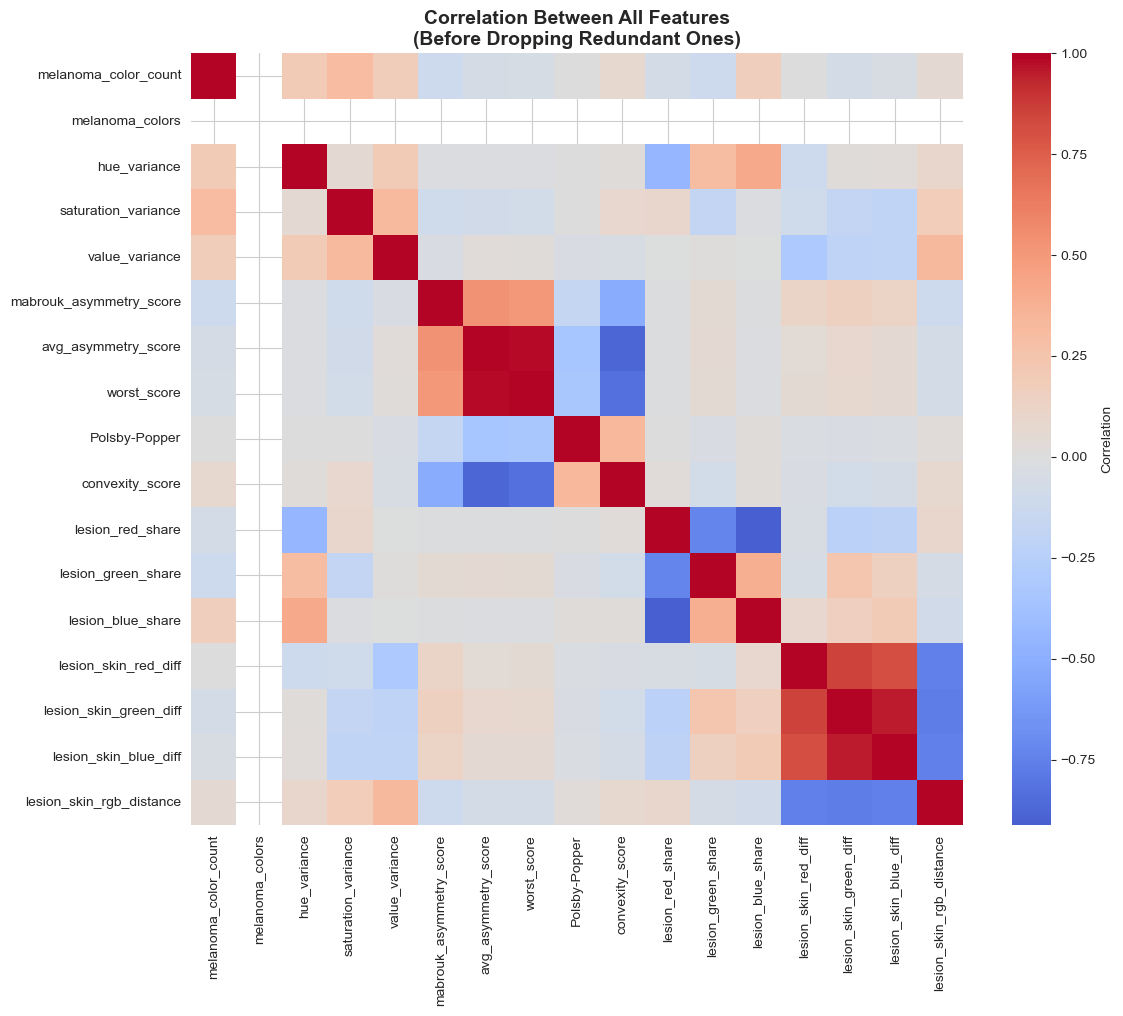

Features are correlated if they have similar information.
Features with >0.8 correlation will be dropped if too many are grouped together.



In [24]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

# ========== PLOT 1: Correlation Matrix Heatmap ==========
print("\n" + "="*60)
print("VISUALIZATION 1: Feature Correlation Matrix")
print("="*60)
print("Red = highly correlated (redundant)")
print("Blue = uncorrelated (different information)\n")

fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = X_trainval.corr()
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0, 
            square=True, cbar_kws={"label": "Correlation"}, ax=ax)
ax.set_title("Correlation Between All Features\n(Before Dropping Redundant Ones)", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Features are correlated if they have similar information.")
print(f"Features with >0.8 correlation will be dropped if too many are grouped together.\n")



VISUALIZATION 2: Why Features Were Dropped?


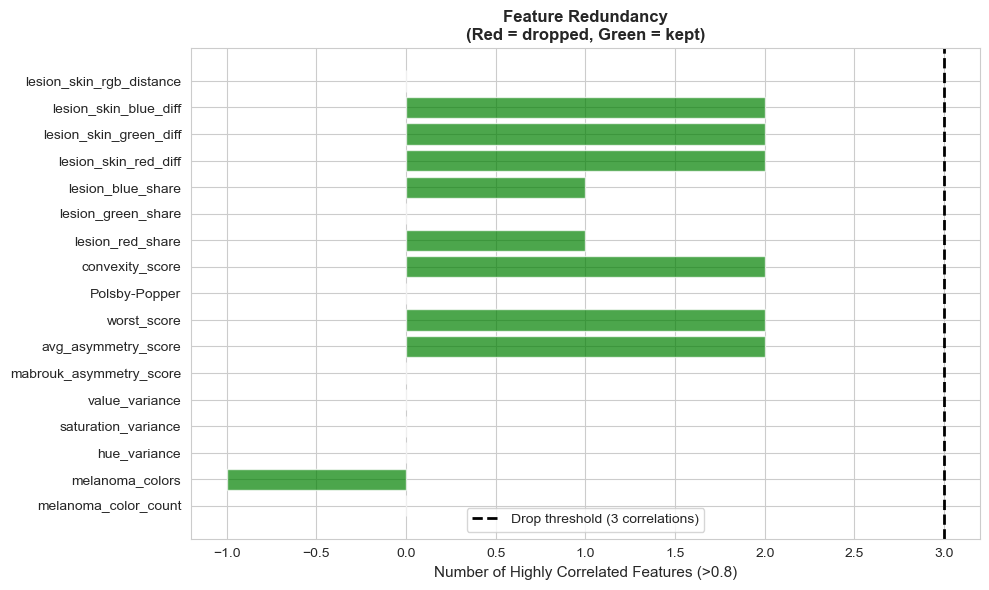


Dropped features: []
Reason: Each had >3 other features that were >0.8 correlated with them
        (Too much redundant information)



In [25]:

# ========== PLOT 2: Why Features Were Dropped ==========
print("\n" + "="*60)
print("VISUALIZATION 2: Why Features Were Dropped?")
print("="*60)

# Show which features have too many correlations
fig, ax = plt.subplots(figsize=(10, 6))
corr = X_trainval.corr().abs().fillna(0)
counts = (corr > threshold).sum(axis=1) - 1

# Separate dropped vs kept
dropped_features = counts[counts > max_allowed].index.tolist()
kept_features = [f for f in counts.index if f not in dropped_features]

colors = ["red" if f in dropped_features else "green" for f in counts.index]
bars = ax.barh(range(len(counts)), counts.values, color=colors, alpha=0.7)

ax.set_yticks(range(len(counts)))
ax.set_yticklabels(counts.index)
ax.axvline(x=max_allowed, color="black", linestyle="--", linewidth=2, 
           label=f"Drop threshold ({max_allowed} correlations)")
ax.set_xlabel("Number of Highly Correlated Features (>0.8)", fontsize=11)
ax.set_title(f"Feature Redundancy\n(Red = dropped, Green = kept)", 
             fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nDropped features: {dropped_features}")
print(f"Reason: Each had >3 other features that were >0.8 correlated with them")
print(f"        (Too much redundant information)\n")



VISUALIZATION 3: Best Features for Cancer Detection


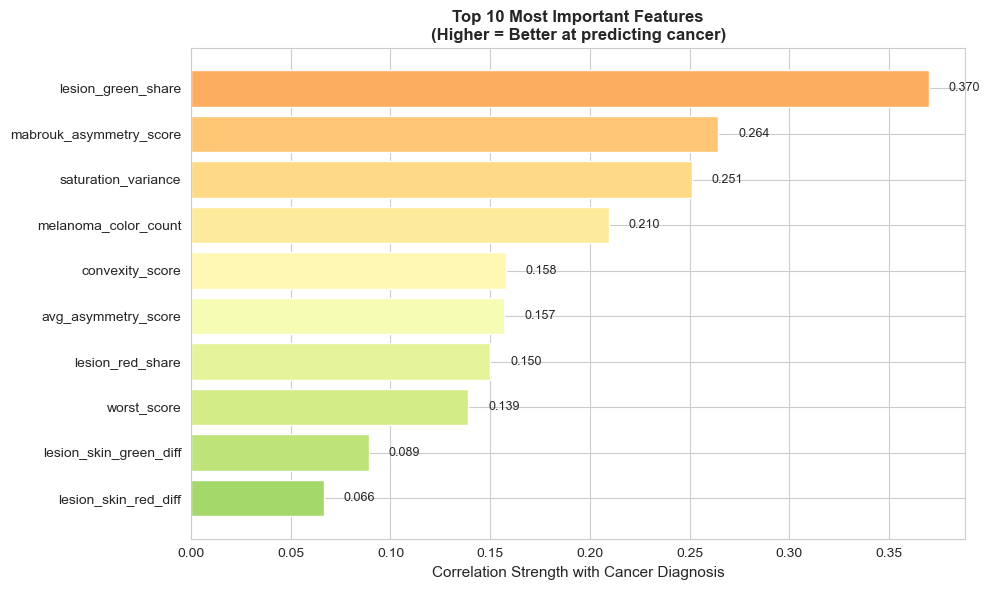


These features have the strongest relationship with cancer diagnosis.
Features at the top are more important for your model!



In [26]:

# ========== PLOT 3: Top Features by Predictive Power ==========
print("\n" + "="*60)
print("VISUALIZATION 3: Best Features for Cancer Detection")
print("="*60)

# Calculate correlation with target
df_rank = X_full_reduced.copy()
df_rank[label_col] = y
corr_with_label = df_rank.corr().abs()[label_col].drop(label_col).fillna(0)
top10_features = corr_with_label.sort_values(ascending=False).head(10)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
colors_gradient = plt.cm.RdYlGn(np.linspace(0.3, 0.7, len(top10_features)))
bars = ax.barh(range(len(top10_features)), top10_features.values, color=colors_gradient)

ax.set_yticks(range(len(top10_features)))
ax.set_yticklabels(top10_features.index)
ax.set_xlabel("Correlation Strength with Cancer Diagnosis", fontsize=11)
ax.set_title("Top 10 Most Important Features\n(Higher = Better at predicting cancer)", 
             fontsize=12, fontweight="bold")
ax.invert_yaxis()

# Add value labels on bars
for i, (feat, val) in enumerate(top10_features.items()):
    ax.text(val + 0.01, i, f"{val:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

print("\nThese features have the strongest relationship with cancer diagnosis.")
print("Features at the top are more important for your model!\n")



VISUALIZATION 4: How Top Features Relate to Cancer Diagnosis


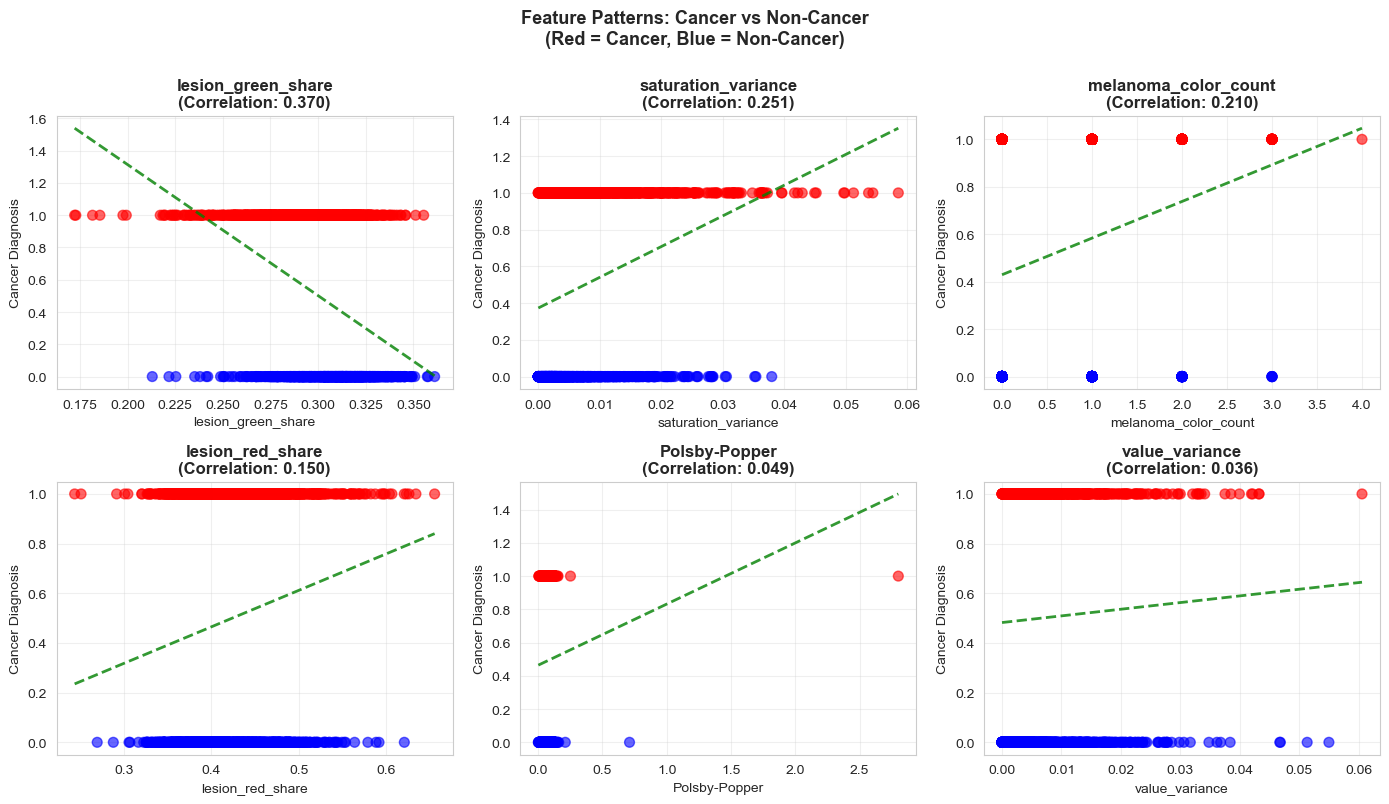

Clear separation = good feature for detection!
Green line shows the trend.



In [20]:

# ========== PLOT 4: Correlation of Top Features with Target ==========
print("\n" + "="*60)
print("VISUALIZATION 4: How Top Features Relate to Cancer Diagnosis")
print("="*60)

# Get top 6 for scatter plots
top6 = corr_with_label.sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, feat in enumerate(top6):
    ax = axes[idx]
    
    # Color by cancer diagnosis
    colors = ["red" if label == 1 else "blue" for label in y]
    ax.scatter(df_rank[feat], df_rank[label_col], c=colors, alpha=0.6, s=50)
    
    # Add trend line
    z = np.polyfit(df_rank[feat].fillna(0), df_rank[label_col], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_rank[feat].min(), df_rank[feat].max(), 100)
    ax.plot(x_line, p(x_line), "g--", linewidth=2, alpha=0.8)
    
    corr_val = corr_with_label[feat]
    ax.set_title(f"{feat}\n(Correlation: {corr_val:.3f})", fontweight="bold")
    ax.set_xlabel(feat)
    ax.set_ylabel("Cancer Diagnosis")
    ax.grid(True, alpha=0.3)

plt.suptitle("Feature Patterns: Cancer vs Non-Cancer\n(Red = Cancer, Blue = Non-Cancer)", 
             fontsize=13, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

print("Clear separation = good feature for detection!")
print("Green line shows the trend.\n")


## Summary: What the Analysis Means

### 🔴 Features That Were Dropped (Why?)
These features were removed because they contained **redundant information** — they're highly correlated with other features already in the model. Keeping them would add noise without adding new predictive power.

### 🟢 Top Features to Use
The green features (ranked chart above) are your **most important predictors**. They have the strongest relationship with cancer diagnosis. These are the features your decision tree/classifier should focus on.

### 💡 Key Insight
- **High Correlation (>0.8)**: Two features measure nearly the same thing → keep only one
- **High Correlation with Target**: A feature is really good at separating cancer from non-cancer → use it!
- **Low Correlation with Target**: A feature doesn't help much → can be removed (less important)

### Next Steps
✅ Use `top10` features for your cancer detection model  
✅ Drop the redundant features to reduce overfitting  
✅ Your model will be simpler, faster, and more interpretable

In [28]:
top10_features.index

Index(['lesion_green_share', 'mabrouk_asymmetry_score', 'saturation_variance',
       'melanoma_color_count', 'convexity_score', 'avg_asymmetry_score',
       'lesion_red_share', 'worst_score', 'lesion_skin_green_diff',
       'lesion_skin_red_diff'],
      dtype='object')

In [21]:

# ========== QUICK STATS ==========
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)

print(f"\n📊 Initial Features: {len(X.columns)}")
print(f"❌ Dropped (redundant): {len(to_drop)}")
print(f"✅ Remaining: {len(X_full_reduced.columns)}")
print(f"🎯 Top Features Selected: {len(top10_features)}")

print(f"\n📈 Feature Importance Range:")
print(f"   Strongest correlation: {top10_features.iloc[0]:.4f} ({top10_features.index[0]})")
print(f"   10th strongest: {top10_features.iloc[-1]:.4f} ({top10_features.index[-1]})")

print(f"\n🚀 Recommendation: Use top {len(top10_features)} features")
print(f"   These explain cancer diagnosis patterns most clearly.")



SUMMARY STATISTICS

📊 Initial Features: 17
❌ Dropped (redundant): 8
✅ Remaining: 9
🎯 Top Features Selected: 9

📈 Feature Importance Range:
   Strongest correlation: 0.3697 (lesion_green_share)
   10th strongest: 0.0000 (melanoma_colors)

🚀 Recommendation: Use top 9 features
   These explain cancer diagnosis patterns most clearly.
